In [1]:
import pandas as pd

orders = pd.read_csv("../data/raw/ecommerce_data/olist_orders_dataset.csv")
customers = pd.read_csv("../data/raw/ecommerce_data/olist_customers_dataset.csv")
order_items = pd.read_csv("../data/raw/ecommerce_data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/ecommerce_data/olist_order_payments_dataset.csv")
leads = pd.read_csv("../data/raw/marketing_funnel_data/olist_marketing_qualified_leads_dataset.csv")
deals = pd.read_csv("../data/raw/marketing_funnel_data/olist_closed_deals_dataset.csv")

for name, df in [("orders", orders), ("customers", customers), ("order_items", order_items),
                  ("payments", payments), ("leads", leads), ("deals", deals)]:
    print(f"\n{name}: {df.shape}")
    print(df.columns.tolist())


orders: (99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

customers: (99441, 5)
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

order_items: (112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

payments: (103886, 5)
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

leads: (8000, 4)
['mql_id', 'first_contact_date', 'landing_page_id', 'origin']

deals: (842, 14)
['mql_id', 'seller_id', 'sdr_id', 'sr_id', 'won_date', 'business_segment', 'lead_type', 'lead_behaviour_profile', 'has_company', 'has_gtin', 'average_stock', 'business_type', 'declared_product_catalog_size', 'declared_monthly_revenue']


In [2]:
import sys
sys.path.append('..')

In [3]:
import numpy as np

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
leads.head()

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


In [6]:
leads['origin'].nunique()


10

In [7]:
leads['origin'].value_counts()


origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
Name: count, dtype: int64

In [8]:
deals.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0


In [9]:
null_count_business_type = deals["business_type"].isna().sum()
null_count_business_segment = deals["business_segment"].isna().sum()
null_count_lead_type = deals["lead_type"].isna().sum()
print(f"Null count for business_type: {null_count_business_type}")
print(f"Null count for business_segment: {null_count_business_segment}")
print(f"Null count for lead_type: {null_count_lead_type}")

Null count for business_type: 10
Null count for business_segment: 1
Null count for lead_type: 6


In [10]:
value_business_type = deals["business_type"].value_counts()
value_business_segment = deals["business_segment"].value_counts()
value_lead_type = deals["lead_type"].value_counts()

print(f"Value counts for business_type:\n{value_business_type}")
print(f"Value counts for business_segment:\n{value_business_segment}")  
print(f"Value counts for lead_type:\n{value_lead_type}")

Value counts for business_type:
business_type
reseller        587
manufacturer    242
other             3
Name: count, dtype: int64
Value counts for business_segment:
business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
sports_leisure                      25
bed_bath_table                      22
bags_backpacks                      22
toys                                20
fashion_accessories                 19
home_office_furniture               14
stationery                          13
phone_mobile                        13
small_appliances                    12
handcrafted                         12
baby                                

In [11]:
import src.db as db


In [12]:
engine = db.get_engine()

DATABASE_URL is set.


In [13]:
query = """
select seller_id, origin, sum(price) as total_revenue
from seller_channel_revenue
group by seller_id, origin

"""

In [14]:
seller_revenue_df = pd.read_sql(query, engine)
print(seller_revenue_df.shape)
seller_revenue_df.head()

(380, 3)


,seller_id,origin,total_revenue
0,596849622429351f47b32e6cae1055ff,unknown,1104.70
1,e1643dff33666ca629e3644c02738179,paid_search,170.00
2,0ddefe3c7a032b91f4e25b9c3a08fca1,paid_search,402.90
3,28872dc528e978a639754bc8c2ce5a4c,paid_search,1009.90
4,382229d1e840115ffe3dbf5ff460e417,organic_search,4096.96


In [15]:
seller_revenue_df.head()

,seller_id,origin,total_revenue
0,596849622429351f47b32e6cae1055ff,unknown,1104.70
1,e1643dff33666ca629e3644c02738179,paid_search,170.00
2,0ddefe3c7a032b91f4e25b9c3a08fca1,paid_search,402.90
3,28872dc528e978a639754bc8c2ce5a4c,paid_search,1009.90
4,382229d1e840115ffe3dbf5ff460e417,organic_search,4096.96


In [16]:
seller_revenue_df = seller_revenue_df.rename(columns={'sum': 'total_revenue'})

In [17]:
channel_stats = seller_revenue_df.groupby(['origin']).agg(
    average_revenue=('total_revenue', 'mean'),
    seller_count=('seller_id', 'count'),
    std_dev=('total_revenue', 'std')
)

channel_stats['std_error'] = channel_stats['std_dev']/np.sqrt(channel_stats['seller_count'])

In [18]:
channel_stats

,average_revenue,seller_count,std_dev,std_error
origin,,,,
direct_traffic,706.577419,31,1152.483861,206.992212
display,461.500000,2,475.882864,336.500000
email,1414.165000,6,2652.907939,1083.045131
organic_search,1832.065929,113,4937.133865,464.446486
other,3444.325000,2,3335.458042,2358.525000
paid_search,1537.396535,101,3903.474048,388.410185
referral,1987.461111,9,2317.927872,772.642624
social,1402.515806,31,2619.887002,470.545596
unknown,2529.238824,85,12361.832895,1340.829035


In [19]:
from scipy import stats


In [20]:

def get_confidence_interval(row):
    lower, upper = stats.t.interval(
        confidence=0.95,
        df=row['seller_count'] - 1,
        loc=row['average_revenue'],
        scale=row['std_error']
    )
    return pd.Series({'ci_lower': lower, 'ci_upper': upper})

channel_stats[['ci_lower', 'ci_upper']] = channel_stats.apply(get_confidence_interval, axis=1)

In [21]:
channel_stats

,average_revenue,seller_count,std_dev,std_error,ci_lower,ci_upper
origin,,,,,,
direct_traffic,706.577419,31,1152.483861,206.992212,283.842926,1129.311913
display,461.500000,2,475.882864,336.500000,-3814.137894,4737.137894
email,1414.165000,6,2652.907939,1083.045131,-1369.891140,4198.221140
organic_search,1832.065929,113,4937.133865,464.446486,911.824753,2752.307105
other,3444.325000,2,3335.458042,2358.525000,-26523.576525,33412.226525
paid_search,1537.396535,101,3903.474048,388.410185,766.801790,2307.991279
referral,1987.461111,9,2317.927872,772.642624,205.744025,3769.178197
social,1402.515806,31,2619.887002,470.545596,441.533496,2363.498117
unknown,2529.238824,85,12361.832895,1340.829035,-137.146757,5195.624404


In [22]:
channel_stats

,average_revenue,seller_count,std_dev,std_error,ci_lower,ci_upper
origin,,,,,,
direct_traffic,706.577419,31,1152.483861,206.992212,283.842926,1129.311913
display,461.500000,2,475.882864,336.500000,-3814.137894,4737.137894
email,1414.165000,6,2652.907939,1083.045131,-1369.891140,4198.221140
organic_search,1832.065929,113,4937.133865,464.446486,911.824753,2752.307105
other,3444.325000,2,3335.458042,2358.525000,-26523.576525,33412.226525
paid_search,1537.396535,101,3903.474048,388.410185,766.801790,2307.991279
referral,1987.461111,9,2317.927872,772.642624,205.744025,3769.178197
social,1402.515806,31,2619.887002,470.545596,441.533496,2363.498117
unknown,2529.238824,85,12361.832895,1340.829035,-137.146757,5195.624404


In [23]:
channel_stats = channel_stats.reset_index()

channel_stats[
    channel_stats["origin"].isin(
        ["organic_search", "paid_search"]
    )
]

,origin,average_revenue,seller_count,std_dev,std_error,ci_lower,ci_upper
3,organic_search,1832.065929,113,4937.133865,464.446486,911.824753,2752.307105
5,paid_search,1537.396535,101,3903.474048,388.410185,766.801790,2307.991279


In [24]:

seller_revenue_organic_search = seller_revenue_df[
    seller_revenue_df["origin"].isin(
        ["organic_search"]
    )
]

In [25]:
seller_revenue_paid_search = seller_revenue_df[
    seller_revenue_df["origin"].isin(
        ["paid_search"]
    )
]

In [26]:
from scipy.stats import ttest_ind

organic_revenue = (
    seller_revenue_organic_search["total_revenue"]
    .dropna()
)

paid_revenue = (
    seller_revenue_paid_search["total_revenue"]
    .dropna()
)

test_result = ttest_ind(
    organic_revenue,
    paid_revenue,
    equal_var=False
)

test_result

TtestResult(statistic=np.float64(0.486692650591654), pvalue=np.float64(0.626986222505963), df=np.float64(208.96611435259058))

In [27]:

query = """
SELECT
    seller_id,
    origin,
    order_purchase_timestamp,
    price,
    DATE_PART('month', age(order_purchase_timestamp ::timestamp,  won_date::timestamp)) AS months_since_joining,
    SUM(price) OVER (
        PARTITION BY seller_id
        ORDER BY order_purchase_timestamp
    ) AS running_revenue
FROM seller_channel_revenue
ORDER BY seller_id, order_purchase_timestamp
"""

cohort_df = pd.read_sql(query, engine)
cohort_df.head()


,seller_id,origin,order_purchase_timestamp,price,months_since_joining,running_revenue
0,01266d4c46afa519678d16a8b683d325,unknown,2018-08-02 16:07:38,9.88,2.0,9.88
1,01266d4c46afa519678d16a8b683d325,unknown,2018-08-19 22:53:16,56.97,3.0,66.85
2,01266d4c46afa519678d16a8b683d325,unknown,2018-08-20 19:14:26,23.40,3.0,90.25
3,01fd077212124329bac32490e8ef80d9,unknown,2018-04-16 10:44:09,17.00,0.0,17.00
4,01fd077212124329bac32490e8ef80d9,unknown,2018-04-17 13:32:54,39.00,0.0,56.00


In [28]:
seller_month_df = (
    cohort_df
    .groupby(
        ["seller_id", "origin", "months_since_joining"],
        as_index=False
    )
    .agg(
        month_end_revenue=("running_revenue", "max")
    )
)

seller_month_df.head()

,seller_id,origin,months_since_joining,month_end_revenue
0,01266d4c46afa519678d16a8b683d325,unknown,2.0,9.88
1,01266d4c46afa519678d16a8b683d325,unknown,3.0,90.25
2,01fd077212124329bac32490e8ef80d9,unknown,0.0,151.00
3,01fd077212124329bac32490e8ef80d9,unknown,1.0,403.00
4,01fd077212124329bac32490e8ef80d9,unknown,2.0,437.00


In [29]:
channel_ramp_df = (
    seller_month_df
    .groupby(
        ["origin", "months_since_joining"],
        as_index=False
    )
    .agg(
        average_revenue=("month_end_revenue", "mean"),
        median_revenue=("month_end_revenue", "median"),
        seller_count=("seller_id", "nunique")
    )
    .sort_values(
        ["origin", "months_since_joining"]
    )
)

channel_ramp_df.head()

,origin,months_since_joining,average_revenue,median_revenue,seller_count
0,direct_traffic,0.0,158.595833,110.55,12
1,direct_traffic,1.0,316.218462,255.00,13
2,direct_traffic,2.0,490.285714,399.00,21
3,direct_traffic,3.0,613.701053,474.00,19
4,direct_traffic,4.0,835.779091,691.90,11


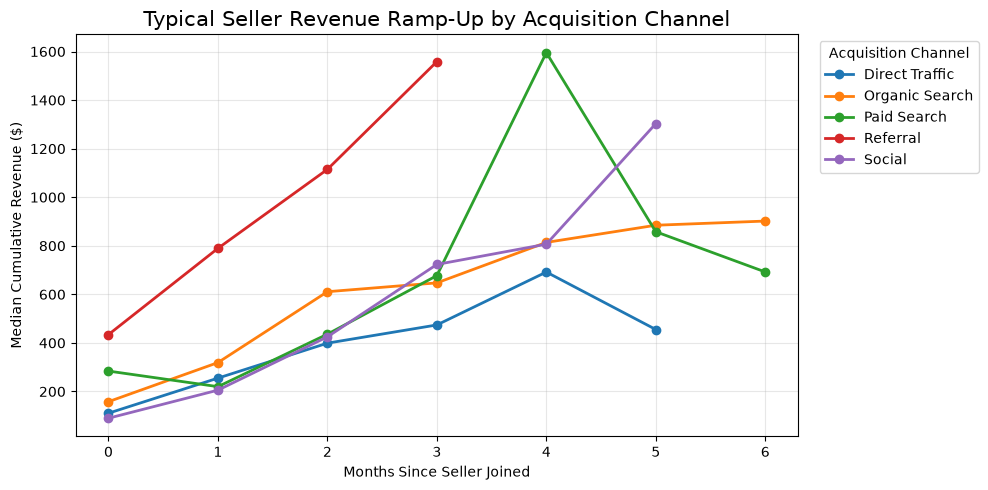

In [30]:
import matplotlib.pyplot as plt

# Clean the month column for the x-axis
channel_ramp_df["months_since_joining"] = (
    channel_ramp_df["months_since_joining"].astype(int)
)

# Remove broad/unclear channel categories
plot_df = channel_ramp_df[
    ~channel_ramp_df["origin"].isin(["unknown", "other"])
].copy()

# Avoid plotting points based on very few sellers
plot_df = plot_df[
    plot_df["seller_count"] >= 5
]

fig, ax = plt.subplots(figsize=(10, 5))

for channel, channel_data in plot_df.groupby("origin"):
    channel_data = channel_data.sort_values("months_since_joining")

    ax.plot(
        channel_data["months_since_joining"],
        channel_data["median_revenue"],
        marker="o",
        linewidth=2,
        label=channel.replace("_", " ").title()
    )

ax.set_title(
    "Typical Seller Revenue Ramp-Up by Acquisition Channel",
    fontsize=15
)

ax.set_xlabel("Months Since Seller Joined")
ax.set_ylabel("Median Cumulative Revenue ($)")

ax.set_xticks(
    sorted(plot_df["months_since_joining"].unique())
)

ax.grid(alpha=0.3)
ax.legend(
    title="Acquisition Channel",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [31]:
seller_count_table = (
    channel_ramp_df
    .pivot(
        index="origin",
        columns="months_since_joining",
        values="seller_count"
    )
)

seller_count_table

months_since_joining,0,1,2,3,4,5,6,7
origin,,,,,,,,
direct_traffic,12.0,13.0,21.0,19.0,11.0,6.0,4.0,NaN
display,NaN,NaN,1.0,2.0,1.0,1.0,NaN,NaN
email,1.0,4.0,2.0,3.0,1.0,NaN,NaN,NaN
organic_search,43.0,59.0,69.0,69.0,43.0,28.0,9.0,2.0
other,1.0,1.0,1.0,2.0,NaN,NaN,1.0,NaN
paid_search,32.0,61.0,61.0,52.0,34.0,20.0,12.0,1.0
referral,5.0,5.0,7.0,6.0,4.0,3.0,1.0,NaN
social,7.0,22.0,21.0,16.0,10.0,6.0,4.0,1.0
unknown,30.0,43.0,54.0,52.0,35.0,17.0,14.0,3.0


In [32]:
seller_count_table.fillna(0).astype(int)

months_since_joining,0,1,2,3,4,5,6,7
origin,,,,,,,,
direct_traffic,12,13,21,19,11,6,4,0
display,0,0,1,2,1,1,0,0
email,1,4,2,3,1,0,0,0
organic_search,43,59,69,69,43,28,9,2
other,1,1,1,2,0,0,1,0
paid_search,32,61,61,52,34,20,12,1
referral,5,5,7,6,4,3,1,0
social,7,22,21,16,10,6,4,1
unknown,30,43,54,52,35,17,14,3


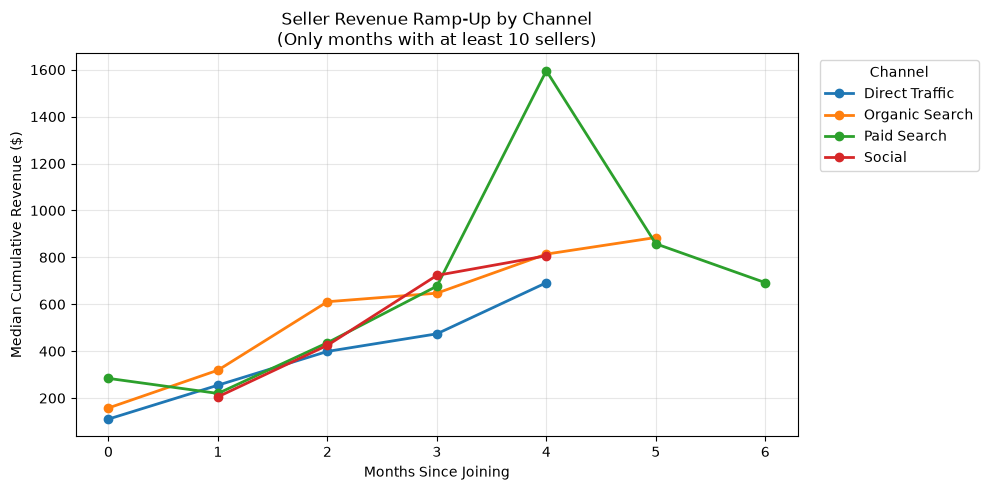

In [33]:
import matplotlib.pyplot as plt

min_sellers = 10

plot_df = channel_ramp_df.copy()
plot_df["months_since_joining"] = plot_df["months_since_joining"].astype(int)

# optional: remove channels that are too sparse / less interpretable
plot_df = plot_df[
    ~plot_df["origin"].isin(["display", "email", "other", "referral", "unknown"])
].copy()

# keep only sufficiently large channel-month groups
plot_df = plot_df[plot_df["seller_count"] >= min_sellers].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for channel, data in plot_df.groupby("origin"):
    data = data.sort_values("months_since_joining")
    ax.plot(
        data["months_since_joining"],
        data["median_revenue"],
        marker="o",
        linewidth=2,
        label=channel.replace("_", " ").title()
    )

ax.set_title("Seller Revenue Ramp-Up by Channel\n(Only months with at least 10 sellers)")
ax.set_xlabel("Months Since Joining")
ax.set_ylabel("Median Cumulative Revenue ($)")
ax.set_xticks(sorted(plot_df["months_since_joining"].unique()))
ax.grid(alpha=0.3)
ax.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [35]:
query = """
SELECT
    seller_id,
    origin,
    won_date,
    order_purchase_timestamp,
    price,
    DATE_PART(
        'month',
        AGE(order_purchase_timestamp::timestamp, won_date::timestamp)
    ) AS months_since_joining,
    SUM(price) OVER (
        PARTITION BY seller_id
        ORDER BY order_purchase_timestamp
    ) AS running_revenue
FROM seller_channel_revenue
ORDER BY seller_id, order_purchase_timestamp
"""

cohort_df_updated = pd.read_sql(query, engine)

cohort_df_updated["won_date"] = pd.to_datetime(cohort_df_updated["won_date"])
cohort_df_updated["order_purchase_timestamp"] = pd.to_datetime(
    cohort_df_updated["order_purchase_timestamp"]
)
cohort_df_updated["months_since_joining"] = (
    cohort_df_updated["months_since_joining"].astype(int)
)

In [37]:
HORIZON = 4

data_end = cohort_df_updated["order_purchase_timestamp"].max()

eligible_sellers = (
    cohort_df_updated[
        ["seller_id", "origin", "won_date"]
    ]
    .drop_duplicates("seller_id")
)

eligible_sellers = eligible_sellers[
    eligible_sellers["won_date"]
    <= data_end - pd.DateOffset(months=HORIZON)
].copy()

print("Eligible sellers:", eligible_sellers["seller_id"].nunique())
print("Data ends:", data_end)

Eligible sellers: 272
Data ends: 2018-08-29 14:52:00


In [38]:
seller_month_df = (
    cohort_df_updated[
        cohort_df_updated["seller_id"].isin(
            eligible_sellers["seller_id"]
        )
    ]
    .query("months_since_joining >= 0")
    .query("months_since_joining <= @HORIZON")
    .groupby(
        ["seller_id", "origin", "months_since_joining"],
        as_index=False
    )
    .agg(
        cumulative_revenue=("running_revenue", "max")
    )
)

In [39]:
months = pd.DataFrame({
    "months_since_joining": range(HORIZON + 1)
})

seller_panel = eligible_sellers.merge(
    months,
    how="cross"
)

seller_panel = seller_panel.merge(
    seller_month_df,
    on=[
        "seller_id",
        "origin",
        "months_since_joining"
    ],
    how="left"
)

seller_panel = seller_panel.sort_values(
    ["seller_id", "months_since_joining"]
)

seller_panel["cumulative_revenue"] = (
    seller_panel
    .groupby("seller_id")["cumulative_revenue"]
    .ffill()
    .fillna(0)
)

In [40]:
proper_ramp_df = (
    seller_panel
    .groupby(
        ["origin", "months_since_joining"],
        as_index=False
    )
    .agg(
        median_revenue=("cumulative_revenue", "median"),
        average_revenue=("cumulative_revenue", "mean"),
        seller_count=("seller_id", "nunique")
    )
)

In [41]:
valid_channels = (
    proper_ramp_df
    .groupby("origin")["seller_count"]
    .first()
    .loc[lambda x: x >= 10]
    .index
)

plot_df = proper_ramp_df[
    proper_ramp_df["origin"].isin(valid_channels)
].copy()

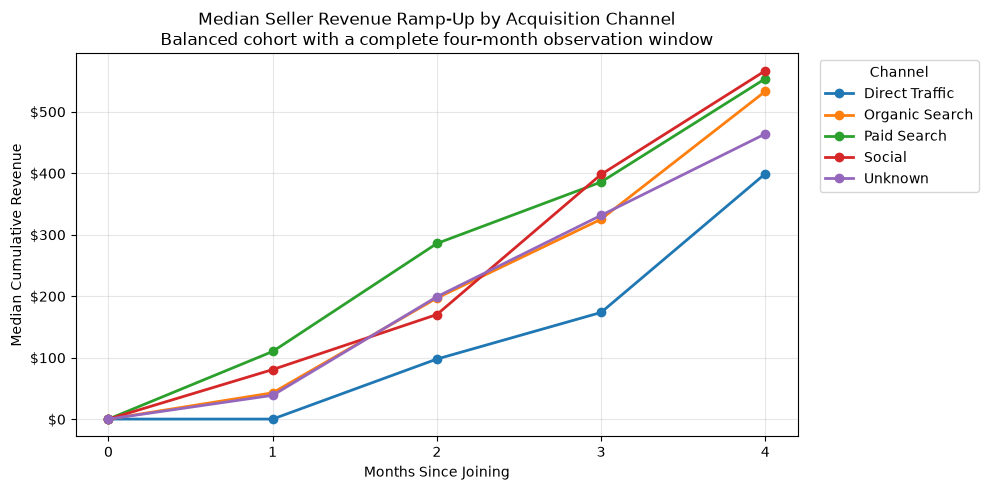

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

fig, ax = plt.subplots(figsize=(10, 5))

for channel, data in plot_df.groupby("origin"):
    data = data.sort_values("months_since_joining")

    ax.plot(
        data["months_since_joining"],
        data["median_revenue"],
        marker="o",
        linewidth=2,
        label=channel.replace("_", " ").title()
    )

ax.set_title(
    "Median Seller Revenue Ramp-Up by Acquisition Channel\n"
    "Balanced cohort with a complete four-month observation window"
)
ax.set_xlabel("Months Since Joining")
ax.set_ylabel("Median Cumulative Revenue")
ax.set_xticks(range(HORIZON + 1))
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.grid(alpha=0.3)
ax.legend(
    title="Channel",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [43]:
proper_ramp_df.pivot(
    index="origin",
    columns="months_since_joining",
    values="seller_count"
)

months_since_joining,0,1,2,3,4
origin,,,,,
direct_traffic,23,23,23,23,23
display,2,2,2,2,2
email,5,5,5,5,5
organic_search,82,82,82,82,82
other,1,1,1,1,1
paid_search,70,70,70,70,70
referral,6,6,6,6,6
social,21,21,21,21,21
unknown,62,62,62,62,62


In [44]:
(
    proper_ramp_df
    .sort_values(["origin", "months_since_joining"])
    .groupby("origin")["median_revenue"]
    .diff()
    .lt(0)
    .sum()
)

np.int64(0)

In [ ]:
seller_level_df = (
    transaction_df
    .groupby(
        ["seller_id", "origin", "business_segment"],
        as_index=False
    )
    .agg(
        total_revenue=("price", "sum")
    )
)

In [45]:
query = """
WITH seller_revenue AS (
    SELECT
        seller_id,
        origin,
        SUM(price) AS total_revenue
    FROM seller_channel_revenue
    GROUP BY
        seller_id,
        origin
)

SELECT
    sr.seller_id,
    sr.origin,
    COALESCE(rd.business_segment, 'unknown') AS business_segment,
    sr.total_revenue
FROM seller_revenue AS sr
LEFT JOIN raw_deal AS rd
    ON sr.seller_id = rd.seller_id
"""

seller_level_df = pd.read_sql(query, engine)

seller_level_df.head()

,seller_id,origin,business_segment,total_revenue
0,596849622429351f47b32e6cae1055ff,unknown,phone_mobile,1104.70
1,e1643dff33666ca629e3644c02738179,paid_search,household_utilities,170.00
2,0ddefe3c7a032b91f4e25b9c3a08fca1,paid_search,household_utilities,402.90
3,28872dc528e978a639754bc8c2ce5a4c,paid_search,household_utilities,1009.90
4,382229d1e840115ffe3dbf5ff460e417,organic_search,household_utilities,4096.96


In [46]:
print("Rows:", len(seller_level_df))
print("Unique sellers:", seller_level_df["seller_id"].nunique())
print(
    "Duplicate sellers:",
    seller_level_df["seller_id"].duplicated().sum()
)

Rows: 380
Unique sellers: 380
Duplicate sellers: 0


In [47]:
segment_counts = (
    seller_level_df
    .groupby("business_segment")["seller_id"]
    .nunique()
    .sort_values(ascending=False)
)

segment_counts

business_segment
health_beauty                      45
home_decor                         44
household_utilities                44
construction_tools_house_garden    32
audio_video_electronics            31
car_accessories                    30
pet                                17
bags_backpacks                     14
sports_leisure                     14
computers                          12
bed_bath_table                     10
toys                               10
food_drink                          9
food_supplement                     8
small_appliances                    7
stationery                          7
baby                                6
fashion_accessories                 6
home_appliances                     5
phone_mobile                        5
books                               4
music_instruments                   4
gifts                               3
home_office_furniture               3
handcrafted                         3
watches                          

In [48]:
minimum_sellers = 10

large_segments = segment_counts[
    segment_counts >= minimum_sellers
].index

seller_level_df["segment_grouped"] = (
    seller_level_df["business_segment"]
    .where(
        seller_level_df["business_segment"].isin(large_segments),
        "other"
    )
)

In [49]:
seller_level_df["segment_grouped"].value_counts()

segment_grouped
other                              77
health_beauty                      45
household_utilities                44
home_decor                         44
construction_tools_house_garden    32
audio_video_electronics            31
car_accessories                    30
pet                                17
sports_leisure                     14
bags_backpacks                     14
computers                          12
toys                               10
bed_bath_table                     10
Name: count, dtype: int64

In [50]:
seller_level_df.loc[
    seller_level_df["business_segment"] == "other"
].shape[0]

0

In [51]:
segment_revenue_df = (
    seller_level_df
    .groupby("segment_grouped", as_index=False)
    .agg(
        seller_count=("seller_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        average_revenue=("total_revenue", "mean"),
        median_revenue=("total_revenue", "median")
    )
    .sort_values("median_revenue", ascending=False)
)

segment_revenue_df

,segment_grouped,seller_count,total_revenue,average_revenue,median_revenue
10,pet,17,40498.83,2382.284118,858.000
2,bed_bath_table,10,15448.53,1544.853000,698.550
12,toys,10,5596.76,559.676000,648.050
8,household_utilities,44,51568.76,1172.017273,592.635
0,audio_video_electronics,31,50265.34,1621.462581,586.570
1,bags_backpacks,14,14233.70,1016.692857,585.210
7,home_decor,44,44102.22,1002.323182,573.300
5,construction_tools_house_garden,32,34538.74,1079.335625,532.865
9,other,77,271493.99,3525.895974,519.200
3,car_accessories,30,30174.98,1005.832667,502.950


In [52]:
segment_revenue_df["mean_median_ratio"] = (
    segment_revenue_df["average_revenue"]
    / segment_revenue_df["median_revenue"]
)

segment_revenue_df[
    [
        "segment_grouped",
        "seller_count",
        "average_revenue",
        "median_revenue",
        "mean_median_ratio"
    ]
].sort_values(
    "mean_median_ratio",
    ascending=False
)

,segment_grouped,seller_count,average_revenue,median_revenue,mean_median_ratio
9,other,77,3525.895974,519.200,6.791017
6,health_beauty,45,2018.573778,405.000,4.984133
4,computers,12,981.024167,315.250,3.111893
11,sports_leisure,14,1165.822857,404.250,2.883916
10,pet,17,2382.284118,858.000,2.776555
0,audio_video_electronics,31,1621.462581,586.570,2.764312
2,bed_bath_table,10,1544.853000,698.550,2.211514
5,construction_tools_house_garden,32,1079.335625,532.865,2.025533
3,car_accessories,30,1005.832667,502.950,1.999866
8,household_utilities,44,1172.017273,592.635,1.977638


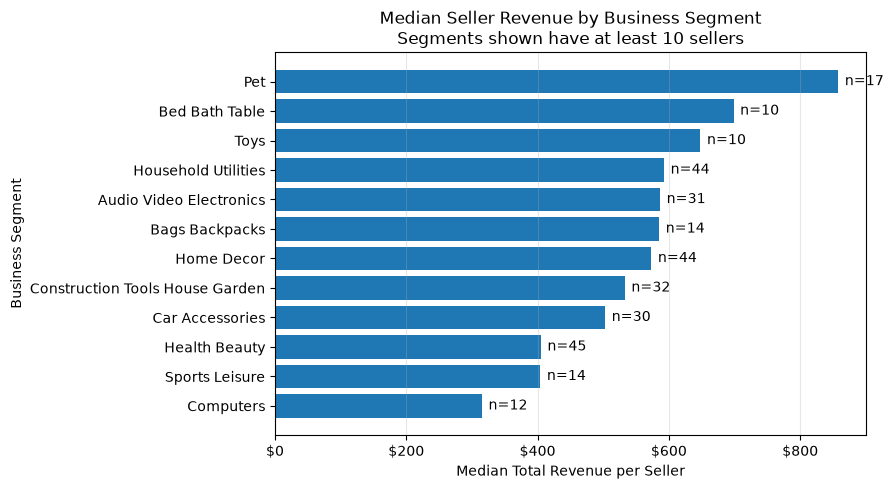

In [54]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

plot_df = (
    segment_revenue_df[
        segment_revenue_df["segment_grouped"] != "other"
    ]
    .sort_values("median_revenue")
    .copy()
)

plot_df["segment_label"] = (
    plot_df["segment_grouped"]
    .str.replace("_", " ")
    .str.title()
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_df["segment_label"],
    plot_df["median_revenue"]
)

ax.set_title(
    "Median Seller Revenue by Business Segment\n"
    "Segments shown have at least 10 sellers"
)
ax.set_xlabel("Median Total Revenue per Seller")
ax.set_ylabel("Business Segment")
ax.xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)
ax.grid(axis="x", alpha=0.3)

for bar, seller_count in zip(
    bars,
    plot_df["seller_count"]
):
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"n={seller_count}",
        va="center"
    )

plt.tight_layout()
plt.show()